In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


In [2]:
nav.columns
benchmark.columns
performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [5]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

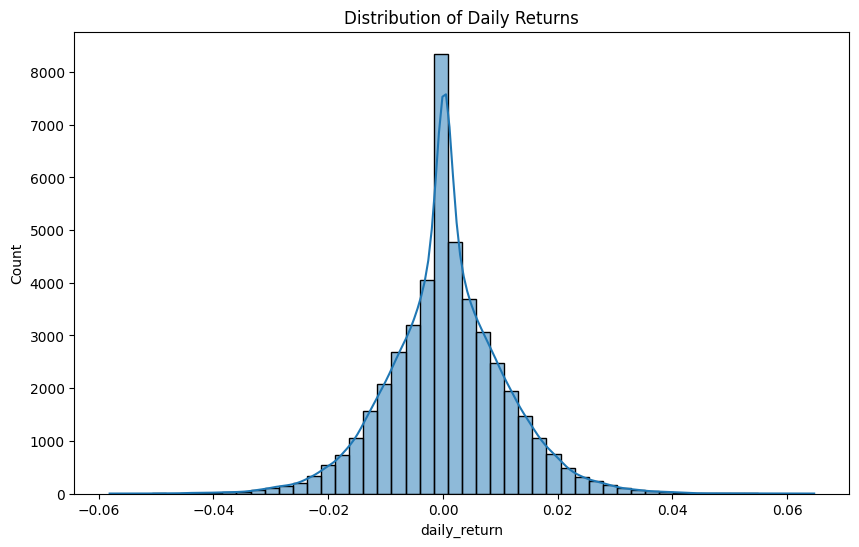

In [8]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

In [9]:
plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = fund_data["nav"].iloc[0]
    end_nav = fund_data["nav"].iloc[-1]

    years = (
        (fund_data["date"].iloc[-1] -
         fund_data["date"].iloc[0]).days
        / 365.25
    )

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)
cagr_df.to_csv(
    "../reports/cagr_table.csv",
    index=False
)

In [12]:
RF = 0.065
sharpe_results = []

for fund in nav["amfi_code"].unique():

    r = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    sharpe = (
        (r.mean()*252 - RF)
        /
        (r.std()*np.sqrt(252))
    )

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [13]:
nav.head()


,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [14]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [15]:
RF = 0.065

sortino_results = []

for fund in nav["amfi_code"].unique():

    r = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    downside = r[r < 0]

    sortino = (
        (r.mean()*252 - RF)
        /
        (downside.std()*np.sqrt(252))
    )

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [16]:
mdd_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].copy()

    running_max = fund_data["nav"].cummax()

    drawdown = (
        fund_data["nav"] /
        running_max
    ) - 1

    max_dd = drawdown.min()

    mdd_results.append(
        [fund, max_dd]
    )

mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

mdd_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [17]:
sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [18]:
mdd_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [19]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [20]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [23]:
nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [24]:
alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]].copy()

    merged = pd.merge(
        fund_data,
        nifty100[["date","benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 50:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [fund, alpha, beta]
        )

In [25]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [26]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [27]:
scorecard = performance.copy()

scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd_df,
    on="amfi_code"
)

In [28]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio_y"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha_y"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(pct=True, ascending=False)
)

scorecard["mdd_rank"] = (
    scorecard["max_drawdown"]
    .rank(pct=True, ascending=False)
)

In [29]:
scorecard["fund_score"] = (

    scorecard["return_rank"] * 30 +

    scorecard["sharpe_rank"] * 25 +

    scorecard["alpha_rank"] * 20 +

    scorecard["expense_rank"] * 15 +

    scorecard["mdd_rank"] * 10

)

In [30]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,sharpe_ratio_y,alpha_y,beta_y,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.945308,0.303370,-0.023196,-0.287060,1.000,0.675,1.000,0.5000,0.900,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,1.180101,0.292636,0.000549,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,0.949796,0.300579,0.011455,-0.311719,0.875,0.700,0.975,0.3625,0.925,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,1.093699,0.271954,0.005104,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.306744,0.273305,-0.022830,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,...,0.998231,0.260767,-0.066265,-0.209609,0.650,0.750,0.800,0.6000,0.700,70.2500
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,...,1.132122,0.265986,-0.002523,-0.172481,0.800,0.875,0.825,0.0750,0.550,69.0000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.448291,0.269838,0.023684,-0.112657,0.600,1.000,0.850,0.4500,0.200,68.7500
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,1.026524,0.211948,0.016232,-0.125883,0.525,0.775,0.700,0.7250,0.300,63.0000
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,Regular,11.16,13.58,14.26,13.04,0.54,...,1.234930,0.282704,0.018134,-0.163967,0.450,0.950,0.925,0.1125,0.525,62.6875


In [31]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [32]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [33]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha_x,...,sharpe_ratio_y,alpha_y,beta_y,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.945308,0.303370,-0.023196,-0.287060,1.000,0.675,1.000,0.5000,0.900,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,1.180101,0.292636,0.000549,-0.181885,0.825,0.900,0.950,0.6500,0.625,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,...,0.949796,0.300579,0.011455,-0.311719,0.875,0.700,0.975,0.3625,0.925,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,...,1.093699,0.271954,0.005104,-0.162172,0.775,0.850,0.875,0.6000,0.500,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.306744,0.273305,-0.022830,-0.129740,0.750,0.975,0.900,0.4750,0.325,75.2500


In [34]:
top5 = scorecard.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5[["amfi_code","scheme_name","fund_score"]]

,amfi_code,scheme_name,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,83.3750
12,120505,ICICI Pru Midcap Fund - Regular - Growth,82.2500
39,149324,DSP Small Cap Fund - Regular - Growth,77.9375
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,76.0000
22,120843,Kotak Flexicap Fund - Regular - Growth,75.2500


In [35]:
nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [36]:
normalized = nav_pivot.copy()

for col in normalized.columns:
    normalized[col] = (
        normalized[col]
        /
        normalized[col].iloc[0]
    ) * 100

In [37]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty50 = nifty50.set_index("date")
nifty100 = nifty100.set_index("date")

nifty50_norm = (
    nifty50["close_value"]
    /
    nifty50["close_value"].iloc[0]
) * 100

nifty100_norm = (
    nifty100["close_value"]
    /
    nifty100["close_value"].iloc[0]
) * 100

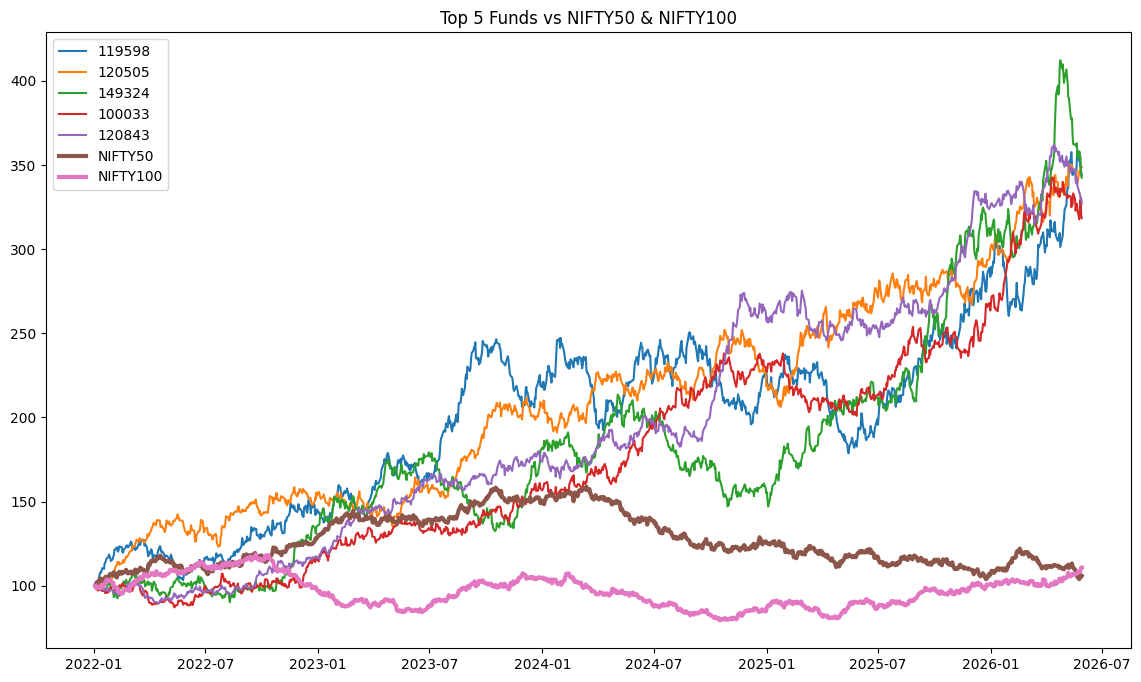

In [38]:
plt.figure(figsize=(14,8))

for fund in top5["amfi_code"]:
    plt.plot(
        normalized.index,
        normalized[fund],
        label=str(fund)
    )

plt.plot(
    nifty50_norm.index,
    nifty50_norm,
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100_norm.index,
    nifty100_norm,
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100"
)

plt.legend()

plt.show()

In [39]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [40]:
fund = top5["amfi_code"].iloc[0]

fund_returns = (
    nav[
        nav["amfi_code"] == fund
    ]
    .set_index("date")["daily_return"]
)

benchmark_returns = (
    nifty100["close_value"]
    .pct_change()
)

merged = pd.concat(
    [fund_returns, benchmark_returns],
    axis=1
).dropna()

tracking_error = (
    (merged.iloc[:,0] - merged.iloc[:,1])
    .std()
    * np.sqrt(252)
)

print(tracking_error)

0.2838814541332667


In [41]:
import os

os.listdir("../reports")

['age_boxplot.png',
 'age_distribution.png',
 'alpha_beta.csv',
 'aum_growth_chart.png',
 'benchmark_comparison.png',
 'Benchmark_Index_Performance.png',
 'cagr_table.csv',
 'category_heatmap.png',
 'daily_return_distribution.png',
 'data_quality_summary.txt',
 'expense_ratio_distribution.png',
 'folio_growth.png',
 'fund_category_count.png',
 'fund_scorecard.csv',
 'gender_distribution.png',
 'nav_correlation_matrix.png',
 'risk_vs_return.png',
 'sector_allocation_donut.png',
 'sip_trend_chart.png',
 'state_distribution.png',
 't30_b30_distribution.png',
 'top_10_funds_by_5-year_return.png',
 'Top_10_portfolio_holdings.png']

In [42]:
cagr_table = []

In [43]:
for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    end_date = fund_data["date"].max()

    end_nav = fund_data["nav"].iloc[-1]

    # 1 Year CAGR
    one_year_data = fund_data[
        fund_data["date"] >= end_date - pd.DateOffset(years=1)
    ]

    cagr_1yr = (
        (end_nav / one_year_data["nav"].iloc[0])
        ** (1/1)
        - 1
    )

    # 3 Year CAGR
    three_year_data = fund_data[
        fund_data["date"] >= end_date - pd.DateOffset(years=3)
    ]

    cagr_3yr = (
        (end_nav / three_year_data["nav"].iloc[0])
        ** (1/3)
        - 1
    )

    # 5 Year CAGR
    five_year_data = fund_data

    years = (
        (five_year_data["date"].iloc[-1]
         - five_year_data["date"].iloc[0]).days
        / 365.25
    )

    cagr_5yr = (
        (end_nav / five_year_data["nav"].iloc[0])
        ** (1/years)
        - 1
    )

    cagr_table.append([
        fund,
        cagr_1yr * 100,
        cagr_3yr * 100,
        cagr_5yr * 100
    ])

In [44]:
cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        "amfi_code",
        "cagr_1yr_pct",
        "cagr_3yr_pct",
        "cagr_5yr_pct"
    ]
)

cagr_df.head()

,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,-2.224271,1.292649,2.637074
1,100025,3.704969,3.916390,4.458210
2,100033,53.232396,32.442459,30.123153
3,101206,47.924120,28.967695,23.538361
4,101207,-23.986032,-4.152381,7.938765


In [45]:
cagr_df.sort_values(
    by="cagr_5yr_pct",
    ascending=False
).head(10)

,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
25,120505,29.604659,31.777537,32.827406
21,119598,82.776059,26.669922,32.423536
39,149324,65.138719,27.000427,32.287440
36,148569,39.751761,29.178902,31.949523
34,148567,20.360678,34.000916,30.974108
30,120843,26.657082,29.582770,30.907455
2,100033,53.232396,32.442459,30.123153
38,149323,21.481222,26.869991,29.581087
16,119094,22.261065,35.111802,28.214417
19,119551,60.437341,30.456524,25.804686


In [46]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR comparison saved successfully")

CAGR comparison saved successfully


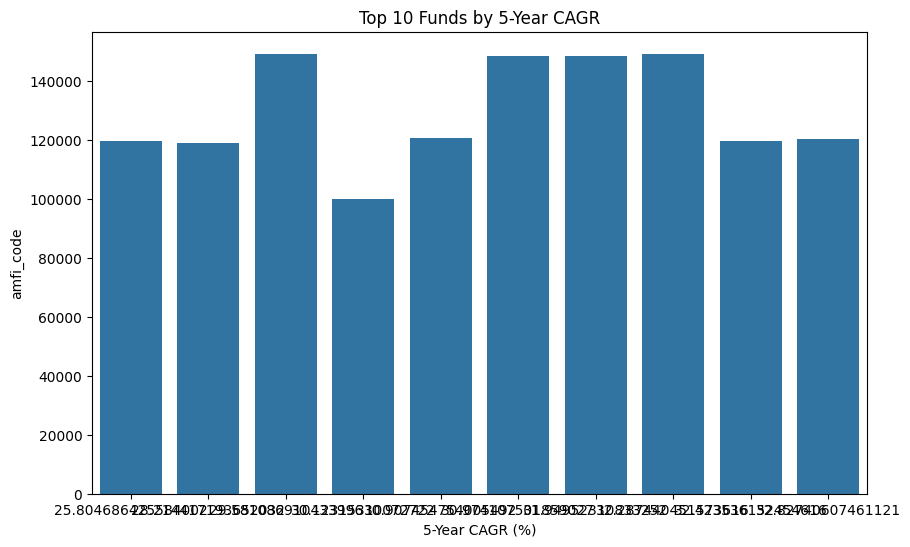

In [47]:
top10_cagr = cagr_df.sort_values(
    "cagr_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_cagr,
    x="cagr_5yr_pct",
    y="amfi_code"
)

plt.title("Top 10 Funds by 5-Year CAGR")

plt.xlabel("5-Year CAGR (%)")

plt.savefig(
    "../reports/top10_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
cagr_df.head()

,amfi_code,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct
0,100016,-2.224271,1.292649,2.637074
1,100025,3.704969,3.916390,4.458210
2,100033,53.232396,32.442459,30.123153
3,101206,47.924120,28.967695,23.538361
4,101207,-23.986032,-4.152381,7.938765
